# LaCAM + PIBT + primitive demo
This notebook builds the dependency-free C++ planner, runs the crossing example, and displays the generated GIF inline.

In [1]:
from pathlib import Path    
import subprocess, sys, yaml
from IPython.display import Image, display
REPO = Path('..').resolve()
sys.path.insert(0, str(REPO / 'python'))
from lacam_primitive_viz import plan_and_animate

In [2]:
subprocess.run(['cmake', '-S', str(REPO), '-B', str(REPO / 'build'), '-DCMAKE_BUILD_TYPE=Release'], check=True)
subprocess.run(['cmake', '--build', str(REPO / 'build'), '-j2'], check=True)

-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kakitsu/tel/lacam_primitive/build
[ 60%] Built target lacam_primitive_core
[ 80%] Built target lacam_primitive_tests
[100%] Built target lacam_primitive


CompletedProcess(args=['cmake', '--build', '/home/kakitsu/tel/lacam_primitive/build', '-j2'], returncode=0)

In [8]:
time_limit_ms = 100000
transition_cache = True
candidate_cache = True
ara_star = True
pixels_per_cell = 12

artifacts = plan_and_animate(
    REPO,
    REPO / 'examples' / 'example.yaml',
    REPO / "outputs" / "notebook_waypoints",
    time_limit_ms=time_limit_ms,
    transition_cache=transition_cache,
    candidate_cache=candidate_cache,
    ara_star=ara_star,
    pixels_per_cell=pixels_per_cell,
    waypoint_only=True,
)

solution improved: cost=15.8 weight=10 search_ms=51376
solution improved: cost=12.2 weight=6.8 search_ms=52192.1
solution improved: cost=11.4 weight=4.8 search_ms=52606.9
precompute static: 106.743 ms (primitive/collision=74.9299, transition_cache=31.8129)
precompute query: 4.20841 ms (candidate_cache=4.19288)
search: 73084.7 ms
warm request: 73088.9 ms
cold total: 73195.7 ms
modes: transition_cache=on candidate_cache=on ara_star=on
cache stats: transition 35191947/35191947 hits, candidate 12608246/12608246 hits, expanded_nodes=200000
Final solution cost: 11.4, search: 73084.7 ms



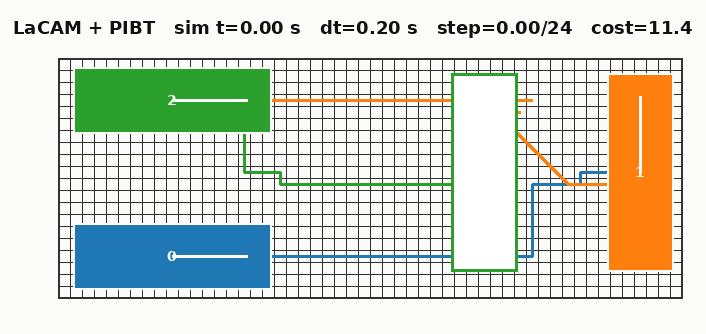

In [9]:
display(Image(filename=str(artifacts['animation'])))

In [10]:
artifacts = plan_and_animate(
    REPO,
    REPO / 'examples' / 'example.yaml',
    REPO / "outputs" / "smooth",
    time_limit_ms=time_limit_ms,
    transition_cache=transition_cache,
    candidate_cache=candidate_cache,
    ara_star=ara_star,
    pixels_per_cell=pixels_per_cell,
)

solution improved: cost=15.8 weight=10 search_ms=53132.9
solution improved: cost=12.2 weight=6.8 search_ms=53998.5
solution improved: cost=11.4 weight=4.8 search_ms=54444.3
precompute static: 119.031 ms (primitive/collision=84.557, transition_cache=34.473)
precompute query: 4.79135 ms (candidate_cache=4.77524)
search: 75660.5 ms
warm request: 75665.3 ms
cold total: 75784.3 ms
modes: transition_cache=on candidate_cache=on ara_star=on
cache stats: transition 35191947/35191947 hits, candidate 12608246/12608246 hits, expanded_nodes=200000
Final solution cost: 11.4, search: 75660.5 ms



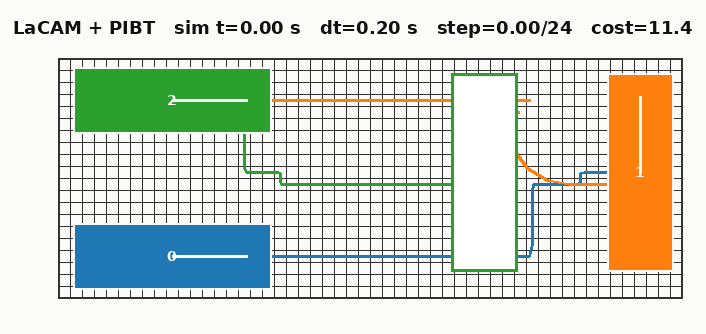

In [11]:
display(Image(filename=str(artifacts['animation'])))

In [12]:
with artifacts['solution'].open(encoding='utf-8') as stream:
    result = yaml.safe_load(stream)
result['improvements'], result['cost']

([{'elapsed_ms': 53132.854611, 'cost': 15.8, 'weight': 10},
  {'elapsed_ms': 53998.472628, 'cost': 12.2, 'weight': 6.8},
  {'elapsed_ms': 54444.256252, 'cost': 11.4, 'weight': 4.8}],
 11.4)